# Grid Layout System

This notebook demonstrates the `GridLayout` system, which provides `subplot2grid`-like functionality with exact inch specifications for cell sizes and gaps.

In [1]:
import numpy as np
import yplot
from yplot import GridSpec, GridLayout, AxisType, create_figure_with_grid, create_grid

## Simplest: create_grid()

For uniform grids where all cells are the same size, use `create_grid()` - a one-liner:

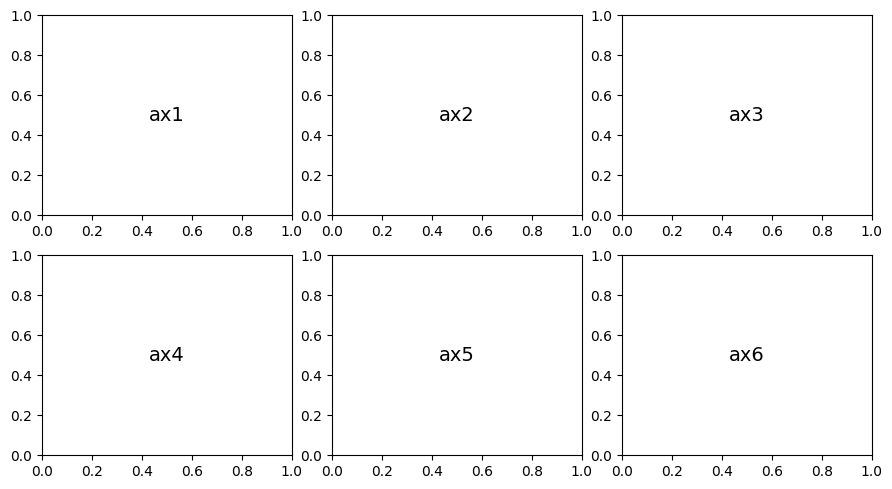

In [2]:
# Simplest way: create_grid() does everything in one call
layout = create_grid(
    rows=2, cols=3,
    cell_width=2.5, cell_height=2.0,
    hgap=0.4, vgap=0.4,
    left=0.5, right=0.1, top=0.1, bottom=0.4  # margins as simple args
)

fig, axes = create_figure_with_grid(layout)

# axes is a list in row-major order: [ax1, ax2, ax3, ax4, ax5, ax6]
for i, ax in enumerate(axes):
    ax.text(0.5, 0.5, f"ax{i+1}", ha="center", va="center", fontsize=14)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

## Using fill() and fill_row()

If you need more control but still want uniform cells, use `fill()` or `fill_row()`:

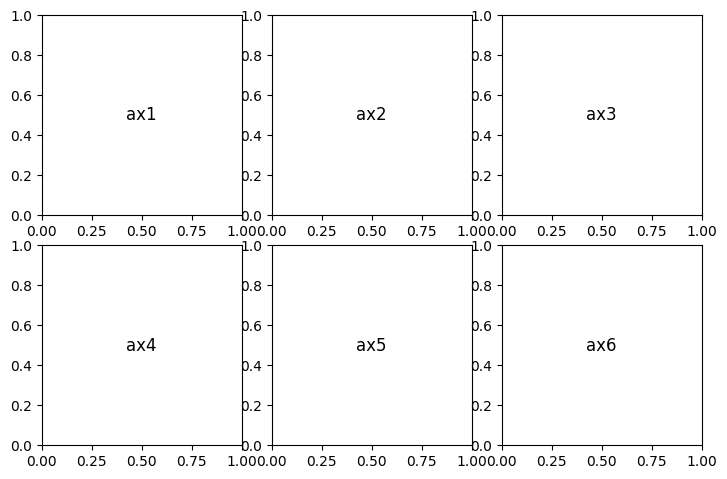

In [3]:
# fill() fills entire grid with 1x1 cells
spec = GridSpec.uniform(rows=2, cols=3, cell_width=2.0, cell_height=2.0, hgap=0.3, vgap=0.3)
layout = GridLayout(spec).fill()  # All 6 cells filled automatically

fig, axes = create_figure_with_grid(layout)
for i, ax in enumerate(axes):
    ax.text(0.5, 0.5, f"ax{i+1}", ha="center", va="center", fontsize=12)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

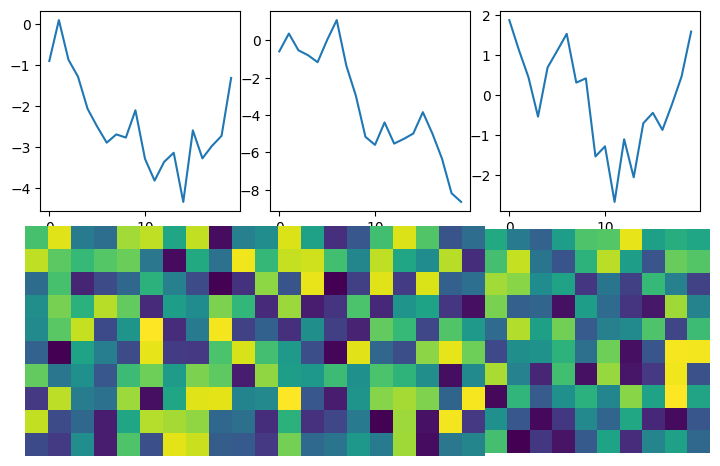

In [4]:
# fill_row() fills one row at a time - useful for different axis types per row
spec = GridSpec.uniform(rows=2, cols=3, cell_width=2.0, cell_height=2.0, hgap=0.3, vgap=0.3)
layout = (
    GridLayout(spec)
    .fill_row(0, axis_type=AxisType.PLOT)   # Top row: normal plots
    .fill_row(1, axis_type=AxisType.IMAGE)  # Bottom row: images
)

fig, axes = create_figure_with_grid(layout)

# Top row: plots with data
for ax in axes[:3]:
    ax.plot(np.random.randn(20).cumsum())
    
# Bottom row: images (no ticks automatically)
for ax in axes[3:]:
    ax.imshow(np.random.rand(10, 10), cmap='viridis')

## Subplot2grid-Style Layout

Replicate matplotlib's `subplot2grid` example with colspan and rowspan:

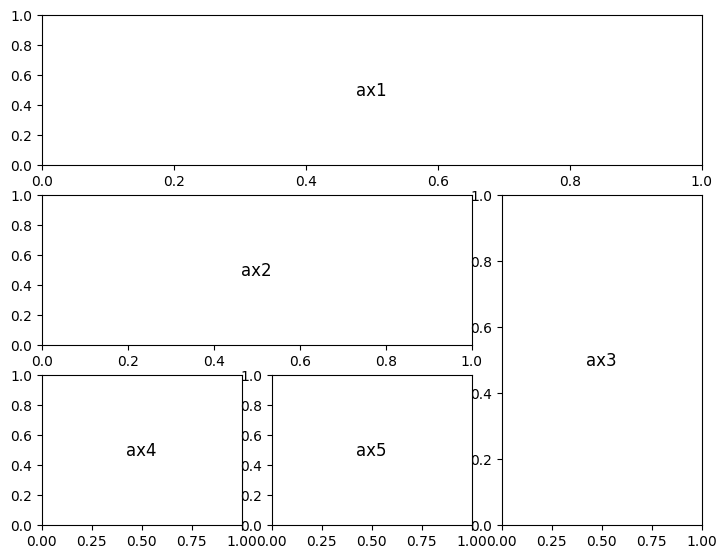

In [11]:
# This replicates:
# ax1 = plt.subplot2grid((3, 3), (0, 0), colspan=3)
# ax2 = plt.subplot2grid((3, 3), (1, 0), colspan=2)
# ax3 = plt.subplot2grid((3, 3), (1, 2), rowspan=2)
# ax4 = plt.subplot2grid((3, 3), (2, 0))
# ax5 = plt.subplot2grid((3, 3), (2, 1))

spec = GridSpec.uniform(
    rows=3, cols=3,
    cell_width=2.0, cell_height=1.5,
    hgap=0.3, vgap=0.3,
    margins={"left": 0.5, "right": 0.1, "top": 0.1, "bottom": 0.4}
)

layout = (
    GridLayout(spec)
    .add_cell(0, 0, colspan=3)  # Top row spans all 3 columns
    .add_cell(1, 0, colspan=2)  # Middle-left spans 2 columns
    .add_cell(1, 2, rowspan=2)  # Right side spans 2 rows
    .add_cell(2, 0)             # Bottom-left
    .add_cell(2, 1)             # Bottom-middle
)

fig, axes = create_figure_with_grid(layout)
ax1, ax2, ax3, ax4, ax5 = axes

# Label each subplot
for i, ax in enumerate(axes):
    ax.text(0.5, 0.5, f"ax{i+1}", ha="center", va="center", fontsize=12)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

## Plot vs Image Axes

Use `AxisType.IMAGE` for subplots that will contain images (no ticks/spines):

Text(0.5, 1.0, 'Line Plot')

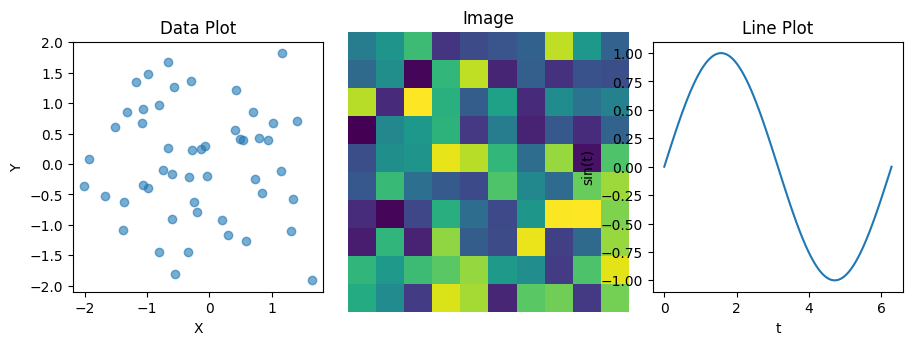

In [6]:
spec = GridSpec.uniform(
    rows=1, cols=3,
    cell_width=2.5, cell_height=2.5,
    hgap=0.4,
)

layout = (
    GridLayout(spec)
    .add_cell(0, 0, axis_type=AxisType.PLOT)   # Left: normal plot with ticks
    .add_cell(0, 1, axis_type=AxisType.IMAGE)  # Middle: image (no ticks)
    .add_cell(0, 2, axis_type=AxisType.PLOT)   # Right: normal plot with ticks
)

fig, axes = create_figure_with_grid(layout)

# Left: scatter plot
x = np.random.randn(50)
y = np.random.randn(50)
axes[0].scatter(x, y, alpha=0.6)
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")
axes[0].set_title("Data Plot")

# Middle: image (note: no ticks/spines automatically)
img = np.random.rand(10, 10)
axes[1].imshow(img, cmap="viridis")
axes[1].set_title("Image")

# Right: line plot
t = np.linspace(0, 2*np.pi, 100)
axes[2].plot(t, np.sin(t))
axes[2].set_xlabel("t")
axes[2].set_ylabel("sin(t)")
axes[2].set_title("Line Plot")

## Non-Uniform Cell Sizes

Specify different widths for each column and heights for each row:

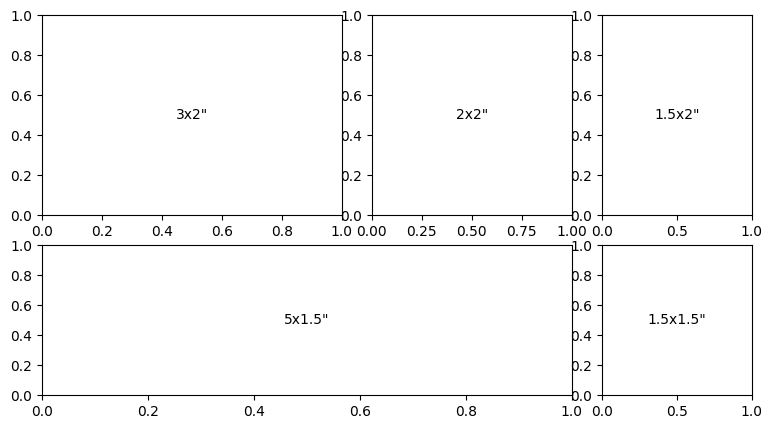

In [7]:
# Different column widths and row heights
spec = GridSpec(
    col_widths=(3.0, 2.0, 1.5),   # Column 0: 3", Column 1: 2", Column 2: 1.5"
    row_heights=(2.0, 1.5),       # Row 0: 2", Row 1: 1.5"
    hgap=0.3,
    vgap=0.3,
    margins=tuple({"left": 0.5, "right": 0.1, "top": 0.1, "bottom": 0.4}.items()),
)

layout = (
    GridLayout(spec)
    .add_cell(0, 0)  # Large top-left
    .add_cell(0, 1)  # Medium top-middle
    .add_cell(0, 2)  # Small top-right
    .add_cell(1, 0, colspan=2)  # Bottom-left spanning 2 columns
    .add_cell(1, 2)  # Small bottom-right
)

fig, axes = create_figure_with_grid(layout)

# Label with sizes
sizes = ["3x2", "2x2", "1.5x2", "5x1.5", "1.5x1.5"]
for ax, size in zip(axes, sizes):
    ax.text(0.5, 0.5, f"{size}\"", ha="center", va="center", fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

## Real-World Example: Publication Figure

A typical publication figure with main plot, inset image, and supplementary panels:

Text(0.5, 0.98, 'Figure 1: Comprehensive Analysis')

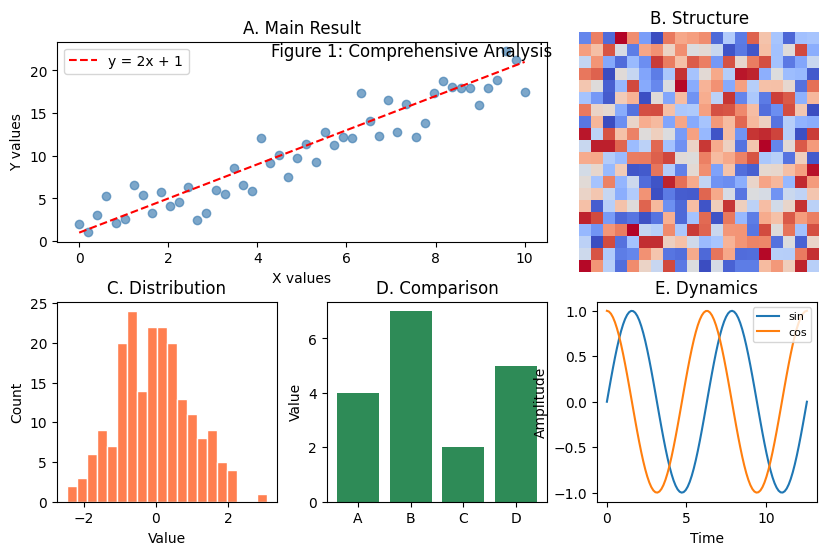

In [8]:
spec = GridSpec.uniform(
    rows=2, cols=3,
    cell_width=2.2, cell_height=2.0,
    hgap=0.5, vgap=0.6,
    margins={"left": 0.6, "right": 0.1, "top": 0.1, "bottom": 0.5}
)

layout = (
    GridLayout(spec)
    .add_cell(0, 0, colspan=2)                    # A: Main plot (wide)
    .add_cell(0, 2, axis_type=AxisType.IMAGE)     # B: Structure image
    .add_cell(1, 0)                               # C: Scatter plot
    .add_cell(1, 1)                               # D: Bar chart
    .add_cell(1, 2)                               # E: Line plot
)

fig, axes = create_figure_with_grid(layout)

# A: Main correlation plot
np.random.seed(42)
x = np.linspace(0, 10, 50)
y = 2 * x + 1 + np.random.randn(50) * 2
axes[0].scatter(x, y, alpha=0.7, c='steelblue')
axes[0].plot(x, 2*x + 1, 'r--', label='y = 2x + 1')
axes[0].set_xlabel('X values')
axes[0].set_ylabel('Y values')
axes[0].legend(loc='upper left')
axes[0].set_title('A. Main Result')

# B: Image placeholder
img = np.random.rand(20, 20)
axes[1].imshow(img, cmap='coolwarm')
axes[1].set_title('B. Structure')

# C: Distribution
data = np.random.randn(200)
axes[2].hist(data, bins=20, color='coral', edgecolor='white')
axes[2].set_xlabel('Value')
axes[2].set_ylabel('Count')
axes[2].set_title('C. Distribution')

# D: Bar chart
categories = ['A', 'B', 'C', 'D']
values = [4, 7, 2, 5]
axes[3].bar(categories, values, color='seagreen')
axes[3].set_ylabel('Value')
axes[3].set_title('D. Comparison')

# E: Time series
t = np.linspace(0, 4*np.pi, 100)
axes[4].plot(t, np.sin(t), label='sin')
axes[4].plot(t, np.cos(t), label='cos')
axes[4].set_xlabel('Time')
axes[4].set_ylabel('Amplitude')
axes[4].legend(loc='upper right', fontsize=8)
axes[4].set_title('E. Dynamics')

fig.suptitle('Figure 1: Comprehensive Analysis', fontsize=12, y=0.98)

## Configuration from Dictionary

You can also create layouts from a dictionary configuration:

Text(0.5, 1.0, 'Image')

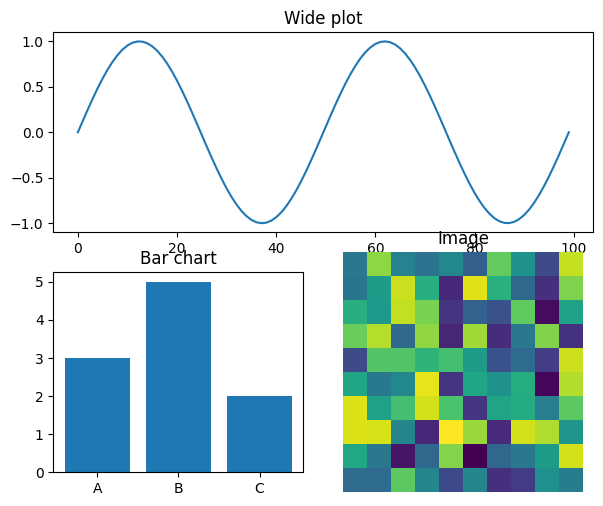

In [9]:
config = {
    "grid": {
        "rows": 2,
        "cols": 2,
        "col_widths": 2.5,      # Uniform width
        "row_heights": 2.0,     # Uniform height
        "hgap": 0.4,
        "vgap": 0.4,
        "margins": {"left": 0.5, "right": 0.1, "top": 0.1, "bottom": 0.4}
    },
    "cells": [
        {"pos": [0, 0], "colspan": 2},              # Top row spans both columns
        {"pos": [1, 0]},                            # Bottom-left
        {"pos": [1, 1], "axis_type": "image"},      # Bottom-right (image)
    ]
}

layout = GridLayout(config=config)
fig, axes = create_figure_with_grid(layout)

# Add content
axes[0].plot(np.sin(np.linspace(0, 4*np.pi, 100)))
axes[0].set_title("Wide plot")

axes[1].bar(['A', 'B', 'C'], [3, 5, 2])
axes[1].set_title("Bar chart")

axes[2].imshow(np.random.rand(10, 10))
axes[2].set_title("Image")

## Saving Layout Configuration

Save your layout to YAML for reuse:

In [10]:
spec = GridSpec.uniform(rows=2, cols=3, cell_width=2.0, cell_height=1.5)
layout = (
    GridLayout(spec)
    .add_cell(0, 0, colspan=2, name="main")
    .add_cell(0, 2, name="sidebar")
    .add_cell(1, 0, name="left")
    .add_cell(1, 1, name="center")
    .add_cell(1, 2, axis_type=AxisType.IMAGE, name="image")
)

# View the configuration
import pprint
pprint.pprint(layout.to_dict())

{'cells': [{'axis_type': 'plot',
            'colspan': 2,
            'name': 'main',
            'pos': [0, 0],
            'rowspan': 1},
           {'axis_type': 'plot',
            'colspan': 1,
            'name': 'sidebar',
            'pos': [0, 2],
            'rowspan': 1},
           {'axis_type': 'plot',
            'colspan': 1,
            'name': 'left',
            'pos': [1, 0],
            'rowspan': 1},
           {'axis_type': 'plot',
            'colspan': 1,
            'name': 'center',
            'pos': [1, 1],
            'rowspan': 1},
           {'axis_type': 'image',
            'colspan': 1,
            'name': 'image',
            'pos': [1, 2],
            'rowspan': 1}],
 'grid': {'col_widths': [2.0, 2.0, 2.0],
          'hgap': 0.3,
          'margins': {'bottom': 0.4, 'left': 0.5, 'right': 0.1, 'top': 0.1},
          'row_heights': [1.5, 1.5],
          'vgap': 0.4}}


## Quick Reference

### Simplest: create_grid()
```python
# One-liner for uniform grids
layout = create_grid(rows=2, cols=3, cell_width=2.5, cell_height=2.0,
                     hgap=0.3, vgap=0.4, left=0.5, right=0.1, top=0.1, bottom=0.4)
fig, axes = create_figure_with_grid(layout)
```

### GridSpec + fill()
```python
# More control over spec, but still auto-fill
spec = GridSpec.uniform(rows=2, cols=3, cell_width=2.5, cell_height=2.0)
layout = GridLayout(spec).fill()
```

### fill_row() for per-row axis types
```python
layout = (
    GridLayout(spec)
    .fill_row(0, axis_type=AxisType.PLOT)   # Row 0: plots
    .fill_row(1, axis_type=AxisType.IMAGE)  # Row 1: images
)
```

### Manual add_cell() for spanning
```python
layout = (
    GridLayout(spec)
    .add_cell(0, 0, colspan=3)              # Span 3 columns
    .add_cell(1, 0, rowspan=2)              # Span 2 rows
    .add_cell(1, 1, axis_type=AxisType.IMAGE)
)
```

### AxisType
- `AxisType.PLOT` - Normal axes with ticks and spines
- `AxisType.IMAGE` - Clean axes for images (no ticks/spines)

## Quick Reference

### GridSpec
```python
# Uniform cells
spec = GridSpec.uniform(rows=3, cols=3, cell_width=2.5, cell_height=2.0)

# Non-uniform cells
spec = GridSpec(
    col_widths=(3.0, 2.0, 1.5),
    row_heights=(2.0, 1.5),
    hgap=0.3, vgap=0.4,
)
```

### GridLayout
```python
layout = GridLayout(spec)
layout.add_cell(row, col, rowspan=1, colspan=1, axis_type=AxisType.PLOT)
```

### AxisType
- `AxisType.PLOT` - Normal axes with ticks and spines
- `AxisType.IMAGE` - Clean axes for images (no ticks/spines)